# 06 Model Training Pipeline

Trains and evaluates models across all three feature strategies (TF-IDF+SVD, Word2Vec, FastText).

| Section | Approach | Type | Tuner |
|---|---|---|---|
| 4 | Isolation Forest | Unsupervised anomaly | Optuna |
| 5 | Autoencoder (PyTorch) | Unsupervised anomaly | Optuna + MedianPruner + per-epoch saves |
| 6 | CASH joint algorithm + hyperparameter search | Supervised classifier | Optuna |

**CASH** (Combined Algorithm Selection and Hyperparameter Optimization): each Optuna trial selects both *which* classifier to use and its hyperparameters simultaneously. The winning algorithm and configuration are then retrained as the final model.

All Optuna studies persist to SQLite under `checkpoints/models/` re-running any cell resumes from where it left off without repeating completed trials.

## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import optuna
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import (
    IsolationForest,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
)
from sklearn.cluster import MiniBatchKMeans
from sklearn.linear_model import SGDOneClassSVM
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
)
import joblib, json, gc, time, warnings
from pathlib import Path
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED      = 42
TRAIN_CAP        = None  # max rows per class when loading 'sup'; None = all
EVAL_CAP         = None  # max rows per class when loading 'val' / 'test'; None = all
PRODUCTION_RATIO = 0.95  # benign fraction in val/test to simulate production (95 % benign)

CKPT_DIR   = Path('checkpoints')
MODELS_DIR = Path('checkpoints/models')
for d in ['isolation_forest', 'kmeans', 'ocsvm', 'autoencoder', 'cash']:
    (MODELS_DIR / d).mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch : {torch.__version__}  |  Optuna : {optuna.__version__}')
print(f'XGBoost : {xgb.__version__}  |  LightGBM: {lgb.__version__}')


class IndexedMmapDataset(Dataset):
    """DataLoader-compatible view into a mmap array via an index array.
    No copy is made  rows are read from disk on demand by each worker.
    """
    def __init__(self, arr: np.ndarray, indices: np.ndarray):
        self.arr = arr
        self.idx = indices

    def __len__(self) -> int:
        return len(self.idx)

    def __getitem__(self, i: int) -> torch.Tensor:
        return torch.from_numpy(self.arr[self.idx[i]].astype(np.float32))


print('Ready.')

Device  : cuda
GPU     : NVIDIA GeForce RTX 5070 Ti
VRAM    : 17.1 GB
PyTorch : 2.10.0+cu128  |  Optuna : 4.7.0
XGBoost : 3.2.0  |  LightGBM: 4.6.0
Ready.


## 2. Load Checkpoints

### 2.1 Feature matrices

All three strategies are loaded as memory maps only the pages that are actually accessed are loaded into RAM.

In [6]:
meta = json.loads((CKPT_DIR / 'meta.json').read_text())

strategies = {
    'tfidf_svd': {
        'X_b': np.load(CKPT_DIR / 'tfidf_svd' / 'X_b.npy', mmap_mode='r'),
        'X_m': np.load(CKPT_DIR / 'tfidf_svd' / 'X_m.npy', mmap_mode='r'),
    },
    'word2vec': {
        'X_b': np.load(CKPT_DIR / 'word2vec' / 'X_b_w2v.npy', mmap_mode='r'),
        'X_m': np.load(CKPT_DIR / 'word2vec' / 'X_m_w2v.npy', mmap_mode='r'),
    },
    # 'fasttext': {   # skipped  1313 dims, HPO would take ~85 h
    #     'X_b': np.load(CKPT_DIR / 'fasttext' / 'X_b_ft.npy', mmap_mode='r'),
    #     'X_m': np.load(CKPT_DIR / 'fasttext' / 'X_m_ft.npy', mmap_mode='r'),
    # },
}

print(f'{"Strategy":<14} {"Benign":<22} {"Malicious":<22} {"Dims":>6}')
for name, d in strategies.items():
    print(f'{name:<14} {str(d["X_b"].shape):<22} {str(d["X_m"].shape):<22} {d["X_b"].shape[1]:>6}')

Strategy       Benign                 Malicious                Dims
tfidf_svd      (1632903, 371)         (3447667, 371)            371
word2vec       (1632903, 353)         (3447667, 353)            353


### 2.2 Define Splits 60 / 20 / 20

| Split | Used for |
|---|---|
| **Train** (60 %) | Unsupervised model fitting; supervised CASH training |
| **Val** (20 %) | Optuna HPO objective never touches test |
| **Test** (20 %) | Final held-out evaluation reported in results table |

`X_train_unsup` is returned as a mmap-backed array so the DataLoader never materialises the full matrix in RAM.
`X_val` and `X_test` are materialised as float32  for very high-dim strategies (FastText) this may require 32 GB+ RAM.

In [7]:
def make_splits(X_b, X_m, train_frac=0.6, val_frac=0.2, seed=SEED):
    """Returns index arrays and mmap references only nothing is materialised.
    Call load_split(s, which) to materialise a split on demand.
    """
    rng = np.random.default_rng(seed)

    def _split3(n):
        idx     = rng.permutation(n)
        tr_end  = int(n * train_frac)
        val_end = int(n * (train_frac + val_frac))
        return idx[:tr_end], idx[tr_end:val_end], idx[val_end:]

    b_tr, b_val, b_te = _split3(len(X_b))
    m_tr, m_val, m_te = _split3(len(X_m))

    dim_gb = X_b.shape[1] * 4 / 1e9
    print(f'  unsup train : {len(b_tr):>9,}  (~{len(b_tr)*dim_gb:.1f} GB when loaded)')
    print(f'  sup train   : {len(b_tr)+len(m_tr):>9,}  (~{(len(b_tr)+len(m_tr))*dim_gb:.1f} GB when loaded)')
    print(f'  val         : {len(b_val)+len(m_val):>9,}  (~{(len(b_val)+len(m_val))*dim_gb:.1f} GB when loaded)')
    print(f'  test        : {len(b_te)+len(m_te):>9,}  (~{(len(b_te)+len(m_te))*dim_gb:.1f} GB when loaded)')

    return {
        'X_b': X_b, 'X_m': X_m,          # mmap refs no RAM used
        'b_tr': b_tr, 'm_tr': m_tr,
        'b_val': b_val, 'm_val': m_val,
        'b_te': b_te,  'm_te': m_te,
        'input_dim': int(X_b.shape[1]),
    }


def load_split(s, which: str, cap: int = None, seed: int = SEED,
               production_ratio: float = None):
    """Materialise a split from mmap indices on demand.

    which            : 'unsup' | 'val' | 'test' | 'sup'
    cap              : max rows *per class* to load (None = all)
    production_ratio : if set (e.g. 0.95), subsample malicious so that
                       benign/(benign+malicious) â‰ˆ production_ratio.
                       Simulates heavy class imbalance seen in production.
                       Only meaningful for 'val' / 'test'.

    Returns (X, y)  y is None for 'unsup'.
    Caller should `del X, y; gc.collect()` after use to free RAM.
    """
    rng = np.random.default_rng(seed)

    if which == 'unsup':
        idx = s['b_tr']
        if cap: idx = rng.choice(idx, min(cap, len(idx)), replace=False)
        return s['X_b'][idx].astype(np.float32), None

    idx_map = {'val': ('b_val', 'm_val'), 'test': ('b_te', 'm_te'), 'sup': ('b_tr', 'm_tr')}
    if which not in idx_map:
        raise ValueError(f'which must be one of {list(idx_map)}')
    bk, mk = idx_map[which]
    bi, mi  = s[bk], s[mk]

    if cap:
        bi = rng.choice(bi, min(cap, len(bi)), replace=False)
        mi = rng.choice(mi, min(cap, len(mi)), replace=False)

    # Simulate production class ratio: keep all benign, subsample malicious
    if production_ratio is not None:
        target_m = max(1, int(len(bi) * (1 - production_ratio) / production_ratio))
        if target_m < len(mi):
            mi = rng.choice(mi, target_m, replace=False)

    X = np.vstack([s['X_b'][bi].astype(np.float32), s['X_m'][mi].astype(np.float32)])
    y = np.concatenate([np.zeros(len(bi)), np.ones(len(mi))]).astype(np.float32)
    return X, y


splits = {}
for name, d in strategies.items():
    print(f'\n{name}  (dim={d["X_b"].shape[1]})')
    splits[name] = make_splits(d['X_b'], d['X_m'])


tfidf_svd  (dim=371)
  unsup train :   979,741  (~1.5 GB when loaded)
  sup train   : 3,048,341  (~4.5 GB when loaded)
  val         : 1,016,114  (~1.5 GB when loaded)
  test        : 1,016,115  (~1.5 GB when loaded)

word2vec  (dim=353)
  unsup train :   979,741  (~1.4 GB when loaded)
  sup train   : 3,048,341  (~4.3 GB when loaded)
  val         : 1,016,114  (~1.4 GB when loaded)
  test        : 1,016,115  (~1.4 GB when loaded)


## 3. Evaluation Utilities

In [8]:
def evaluate(scores, y_true, model_name, strategy):
    """scores: higher value = more anomalous / more likely malicious."""
    roc  = float(roc_auc_score(y_true, scores))
    ap   = float(average_precision_score(y_true, scores))
    prec, rec, thr = precision_recall_curve(y_true, scores)
    f1s  = 2 * prec * rec / (prec + rec + 1e-9)
    best = int(np.argmax(f1s))
    f1   = float(f1s[best])
    thr_opt = float(thr[best]) if best < len(thr) else float(thr[-1])
    # TPR at fixed FPR operating points
    fpr, tpr, _ = roc_curve(y_true, scores)
    tpr_at_1fpr  = float(tpr[np.searchsorted(fpr, 0.01,  side='right') - 1])
    tpr_at_01fpr = float(tpr[np.searchsorted(fpr, 0.001, side='right') - 1])
    return {
        'model':         model_name,
        'strategy':      strategy,
        'roc_auc':       round(roc,         4),
        'avg_precision': round(ap,           4),
        'f1':            round(f1,           4),
        'tpr@1%fpr':     round(tpr_at_1fpr,  4),
        'tpr@0.1%fpr':   round(tpr_at_01fpr, 4),
        'threshold':     round(thr_opt,      6),
    }


def _report_boundaries(study, bounds: dict, tol: float = 0.10):
    """Flag best-trial params within `tol` fraction of their search bounds.

    bounds: {param_name: (lo, hi, kind)}  kind='int'|'float'|'log'|'cat'
    Categorical params are skipped (no natural ordering).
    """
    best = study.best_trial.params
    hits = []
    for k, (lo, hi, kind) in bounds.items():
        if k not in best or kind == 'cat':
            continue
        v   = best[k]
        pos = (v - lo) / (hi - lo) if (hi - lo) > 0 else 0.5
        if pos <= tol:
            hits.append(f'    ⚠  {k}={v:.4g}  — near LOWER bound ({lo}), consider decreasing')
        elif pos >= 1 - tol:
            hits.append(f'    ⚠  {k}={v:.4g}  — near UPPER bound ({hi}), consider increasing')
    if hits:
        print('  Boundary saturation (expand search space if re-running):')
        for h in hits:
            print(h)
    else:
        print('  No boundary saturation detected.')


def _trial_callback(study, trial):
    """Print per-trial summary + ETA after each completed Optuna trial.
    Objectives may store extra metrics via trial.set_user_attr().
    """
    if trial.state != optuna.trial.TrialState.COMPLETE:
        print(f'  Trial {trial.number:>3}  FAILED')
        return
    completed = [t for t in study.trials
                 if t.state == optuna.trial.TrialState.COMPLETE]
    n_done  = len(completed)
    recent  = sorted(completed, key=lambda t: t.number)[-5:]
    durs    = [(t.datetime_complete - t.datetime_start).total_seconds()
               for t in recent if t.datetime_complete and t.datetime_start]
    avg_s   = sum(durs) / len(durs) if durs else 0
    eta_str = ''
    if avg_s and hasattr(study, '_storage'):
        try:
            n_total     = study.sampler._n_startup_trials  # may not exist
        except AttributeError:
            n_total = None
    if avg_s:
        # derive remaining from n_trials passed to optimize (stored on study)
        n_total = getattr(study, '_n_trials_arg', None)
        if n_total:
            remaining_s = avg_s * (n_total - n_done)
            h, rem = divmod(int(remaining_s), 3600)
            m, _   = divmod(rem, 60)
            eta_str = f'  ETA~{h:02d}h{m:02d}m  avg={avg_s:.0f}s/trial'
        else:
            eta_str = f'  avg={avg_s:.0f}s/trial'
    # extra metrics stored by the objective
    attrs      = trial.user_attrs
    metric_str = f'AP={trial.value:.4f}'
    if 'roc_auc' in attrs: metric_str += f'  ROC-AUC={attrs["roc_auc"]:.4f}'
    if 'f1'      in attrs: metric_str += f'  F1={attrs["f1"]:.4f}'
    p   = trial.params
    fmt = '  '.join(
        f'{k}={v:.3g}' if isinstance(v, float) else f'{k}={v}'
        for k, v in p.items()
    )
    print(f'  Trial {trial.number:>3}  {metric_str}  '
          f'best={study.best_value:.4f}{eta_str}  |  {fmt}')


results = []   # accumulate across all models x strategies
print('Evaluation utilities ready.')

Evaluation utilities ready.


## 4. Unsupervised Anomaly Detectors

Three scalable families are tested  each trained on benign-only data and scored with higher = more anomalous:

| Model | Family | Score |
|---|---|---|
| Isolation Forest | Ensemble (tree-based) | `-score_samples(x)` |
| MiniBatchKMeans | Clustering | distance to nearest centroid |
| SGDOneClassSVM | Boundary (linear) | `-score_samples(x)` |

### 4.1 Isolation Forest

In [ ]:
N_IF_TRIALS = 50
IF_DIR      = MODELS_DIR / 'isolation_forest'

if_best  = {}
_if_path = IF_DIR / 'best_params.json'
if _if_path.exists():
    if_best = json.loads(_if_path.read_text())
    print(f'Loaded IF best params for: {list(if_best.keys())}')

for name, s in splits.items():
    if name in if_best:
        print(f'{name}: already optimised  skipping.')
        continue

    X_val, y_val = load_split(s, 'val', cap=EVAL_CAP, production_ratio=PRODUCTION_RATIO)
    X_tr,  _     = load_split(s, 'unsup')   # load once  not per trial
    # n_jobs: each worker copies ~dim x n_samples x 4 bytes; cap for large dims
    worker_gb = s['input_dim'] * len(s['b_tr']) * 4 / 1e9
    n_if_jobs = 1 if worker_gb > 3.0 else 6
    print(f'  {name}: X_tr={X_tr.nbytes/1e9:.2f} GB  worker_copy={worker_gb:.2f} GB  n_jobs={n_if_jobs}')

    storage = f'sqlite:///{IF_DIR}/{name}_study.db'
    study   = optuna.create_study(
        study_name=f'IF_{name}_ap', storage=storage,
        direction='maximize', load_if_exists=True,
    )
    done      = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
    remaining = max(0, N_IF_TRIALS - done)

    def _if_obj(trial, _xt=X_tr, _xv=X_val, _yv=y_val, _nj=n_if_jobs):
        clf = IsolationForest(
            n_estimators = trial.suggest_int('n_estimators',   50, 1000),
            max_samples  = trial.suggest_float('max_samples',  0.05, 1.0),
            max_features = trial.suggest_float('max_features', 0.1,  1.0),
            n_jobs=_nj, random_state=SEED,
        )
        clf.fit(_xt)
        scores = -clf.score_samples(_xv)
        return average_precision_score(_yv, scores)

    print(f'{name}: {done}/{N_IF_TRIALS} done  running {remaining} more...')
    study.optimize(_if_obj, n_trials=remaining, show_progress_bar=True,
                   callbacks=[_trial_callback])
    _report_boundaries(study, {
        'n_estimators': (50,   1000, 'int'),
        'max_samples':  (0.05, 1.0,  'float'),
        'max_features': (0.1,  1.0,  'float'),
    })
    if_best[name] = study.best_params
    print(f'  best AP={study.best_value:.4f}  {study.best_params}')
    del X_tr, X_val, y_val; gc.collect()

_if_path.write_text(json.dumps(if_best, indent=2))
print('IF best params saved.')

  tfidf_svd: X_tr=1.45 GB  worker_copy=1.45 GB  n_jobs=6
tfidf_svd: 50/50 done â€” running 0 more...
  Boundary saturation (expand search space if re-running):
    âš   max_samples=0.9801  â€” near UPPER bound (1.0), consider increasing
    âš   max_features=0.1033  â€” near LOWER bound (0.1), consider decreasing
  best AP=0.4633  {'n_estimators': 902, 'max_samples': 0.9801391584714183, 'max_features': 0.10325512042230052}
  word2vec: X_tr=1.38 GB  worker_copy=1.38 GB  n_jobs=6
word2vec: 15/50 done â€” running 35 more...


  0%|          | 0/35 [00:00<?, ?it/s]

  Trial  16  AP=0.5101  best=0.5328  |  n_estimators=994  max_samples=0.921  max_features=0.485
  Trial  17  AP=0.5151  best=0.5328  |  n_estimators=681  max_samples=0.641  max_features=0.901
  Trial  18  AP=0.5137  best=0.5328  |  n_estimators=828  max_samples=0.631  max_features=0.998
  Trial  19  AP=0.5058  best=0.5328  |  n_estimators=582  max_samples=0.902  max_features=0.354
  Trial  20  AP=0.5045  best=0.5328  |  n_estimators=790  max_samples=0.421  max_features=0.709
  Trial  21  AP=0.5354  best=0.5354  |  n_estimators=993  max_samples=0.9  max_features=0.834
  Trial  22  AP=0.5228  best=0.5354  |  n_estimators=977  max_samples=0.9  max_features=0.832
  Trial  23  AP=0.4986  best=0.5354  |  n_estimators=920  max_samples=0.733  max_features=0.752
  Trial  24  AP=0.5331  best=0.5354  |  n_estimators=771  max_samples=0.932  max_features=0.881
  Trial  25  AP=0.5362  best=0.5362  |  n_estimators=614  max_samples=0.622  max_features=0.903
  Trial  26  AP=0.5243  best=0.5362  |  n_es

  0%|          | 0/50 [00:00<?, ?it/s]

  Trial   0  AP=0.1959  best=0.1959  |  n_estimators=511  max_samples=0.565  max_features=0.817
[W 2026-03-27 21:34:14,018] Trial 1 failed with parameters: {'n_estimators': 558, 'max_samples': 0.4535711319047659, 'max_features': 0.28229870678950886} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\cesar\miniforge3\envs\cyber-anomaly\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "F:\GECAD\_cache\tmp\ipykernel_22068\3864251778.py", line 37, in _if_obj
    clf.fit(_xt)
  File "c:\Users\cesar\miniforge3\envs\cyber-anomaly\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\cesar\miniforge3\envs\cyber-anomaly\Lib\site-packages\sklearn\ensemble\_iforest.py", line 358, in fit
    super()._fit(
  File "c:\Users\cesar\min

KeyboardInterrupt: 

### 4.2 MiniBatchKMeans

Clusters the benign distribution into `k` compact centroids with a streaming mini-batch update rule.
Anomaly score = distance to the nearest centroid  events far from any learned cluster are flagged.

In [ ]:
N_KM_TRIALS = 50
KM_DIR      = MODELS_DIR / 'kmeans'

km_best  = {}
_km_path = KM_DIR / 'best_params.json'
if _km_path.exists():
    km_best = json.loads(_km_path.read_text())
    print(f'Loaded KMeans best params for: {list(km_best.keys())}')

for name, s in splits.items():
    if name in km_best:
        print(f'{name}: already optimised  skipping.')
        continue

    X_val, y_val = load_split(s, 'val', cap=EVAL_CAP, production_ratio=PRODUCTION_RATIO)
    X_tr,  _     = load_split(s, 'unsup')   # load once  not per trial

    storage = f'sqlite:///{KM_DIR}/{name}_study.db'
    study   = optuna.create_study(
        study_name=f'KM_{name}_ap', storage=storage,
        direction='maximize', load_if_exists=True,
    )
    done      = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
    remaining = max(0, N_KM_TRIALS - done)

    def _km_obj(trial, _xt=X_tr, _xv=X_val, _yv=y_val):
        clf = MiniBatchKMeans(
            n_clusters   = trial.suggest_int('n_clusters',  4,   512),
            batch_size   = trial.suggest_categorical('batch_size', [1024, 4096, 16384, 65536]),
            max_iter     = trial.suggest_int('max_iter',    100, 1000),
            n_init       = trial.suggest_int('n_init',      3,   20),
            random_state = SEED,
        )
        clf.fit(_xt)
        scores = clf.transform(_xv).min(axis=1)
        return average_precision_score(_yv, scores)

    print(f'{name}: {done}/{N_KM_TRIALS} done  running {remaining} more...')
    study.optimize(_km_obj, n_trials=remaining, show_progress_bar=True)
    _report_boundaries(study, {
        'n_clusters': (4,   512,  'int'),
        'max_iter':   (100, 1000, 'int'),
        'n_init':     (3,   20,   'int'),
    })
    km_best[name] = study.best_params
    print(f'  best AP={study.best_value:.4f}  {study.best_params}')
    del X_tr, X_val, y_val; gc.collect()

_km_path.write_text(json.dumps(km_best, indent=2))
print('KMeans best params saved.')

tfidf_svd: 50/50 done â€” running 0 more...
  Boundary saturation (expand search space if re-running):
    âš   n_clusters=509  â€” near UPPER bound (512), consider increasing
  best AP=0.5265  {'n_clusters': 509, 'batch_size': 4096, 'max_iter': 371, 'n_init': 5}
word2vec: 49/50 done â€” running 1 more...


  0%|          | 0/1 [00:00<?, ?it/s]

  Boundary saturation (expand search space if re-running):
    âš   n_clusters=490  â€” near UPPER bound (512), consider increasing
  best AP=0.6736  {'n_clusters': 490, 'batch_size': 65536, 'max_iter': 351, 'n_init': 10}
KMeans best params saved.


### 4.3 SGDOneClassSVM

Linear-time one-class boundary learned with stochastic gradient descent.
Fits a linear separator around the benign distribution; anomaly score = `-score_samples(x)`.
Scales to millions of rows without subsampling.

In [ ]:
N_OC_TRIALS = 40
OC_DIR      = MODELS_DIR / 'ocsvm'

oc_best  = {}
_oc_path = OC_DIR / 'best_params.json'
if _oc_path.exists():
    oc_best = json.loads(_oc_path.read_text())
    print(f'Loaded OCSVM best params for: {list(oc_best.keys())}')

for name, s in splits.items():
    if name in oc_best:
        print(f'{name}: already optimised  skipping.')
        continue

    X_val, y_val = load_split(s, 'val', cap=EVAL_CAP, production_ratio=PRODUCTION_RATIO)
    X_tr,  _     = load_split(s, 'unsup')   # load once  not per trial

    storage = f'sqlite:///{OC_DIR}/{name}_study.db'
    study   = optuna.create_study(
        study_name=f'OC_{name}_ap', storage=storage,
        direction='maximize', load_if_exists=True,
    )
    done      = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
    remaining = max(0, N_OC_TRIALS - done)

    def _oc_obj(trial, _xt=X_tr, _xv=X_val, _yv=y_val):
        clf = SGDOneClassSVM(
            nu            = trial.suggest_float('nu',      0.001, 0.9),
            learning_rate = trial.suggest_categorical('learning_rate',
                                ['optimal', 'invscaling', 'constant']),
            eta0          = trial.suggest_float('eta0',   1e-5, 1.0, log=True),
            max_iter      = trial.suggest_int('max_iter', 500,  5000),
            random_state  = SEED,
        )
        clf.fit(_xt)
        scores = -clf.score_samples(_xv)
        ap  = average_precision_score(_yv, scores)
        roc = roc_auc_score(_yv, scores)
        prec, rec, _ = precision_recall_curve(_yv, scores)
        f1s = 2 * prec * rec / (prec + rec + 1e-9)
        trial.set_user_attr('roc_auc', round(float(roc),         4))
        trial.set_user_attr('f1',      round(float(f1s.max()),   4))
        return ap

    print(f'{name}: {done}/{N_OC_TRIALS} done  running {remaining} more...')
    study.optimize(_oc_obj, n_trials=remaining, show_progress_bar=True,
                   callbacks=[_trial_callback])
    _report_boundaries(study, {
        'nu':       (0.001, 0.9,  'float'),
        'eta0':     (1e-5,  1.0,  'log'),
        'max_iter': (500,   5000, 'int'),
    })
    oc_best[name] = study.best_params
    print(f'  best AP={study.best_value:.4f}  {study.best_params}')
    del X_tr, X_val, y_val; gc.collect()

_oc_path.write_text(json.dumps(oc_best, indent=2))
print('OCSVM best params saved.')

tfidf_svd: 40/40 done â€” running 0 more...
  No boundary saturation detected.
  best AP=0.2025  {'nu': 0.36831864472300674, 'learning_rate': 'constant', 'eta0': 0.8835151326573215, 'max_iter': 3010}
word2vec: 7/40 done â€” running 33 more...


  0%|          | 0/33 [00:00<?, ?it/s]

  Trial   8  AP=0.0795  ROC-AUC=0.5422  F1=0.1481  best=0.1678  avg=398s/trial  |  nu=0.116  learning_rate=constant  eta0=0.074  max_iter=2529
  Trial   9  AP=0.1655  ROC-AUC=0.8557  F1=0.3925  best=0.1678  avg=363s/trial  |  nu=0.504  learning_rate=constant  eta0=0.0658  max_iter=922
  Trial  10  AP=0.0299  ROC-AUC=0.0533  F1=0.0952  best=0.1678  avg=301s/trial  |  nu=0.845  learning_rate=optimal  eta0=0.074  max_iter=4757
  Trial  11  AP=0.0781  ROC-AUC=0.4894  F1=0.1808  best=0.1678  avg=378s/trial  |  nu=0.29  learning_rate=constant  eta0=1.05e-05  max_iter=3568
  Trial  12  AP=0.1668  ROC-AUC=0.8524  F1=0.3908  best=0.1678  avg=366s/trial  |  nu=0.514  learning_rate=constant  eta0=1.31e-05  max_iter=577
  Trial  13  AP=0.0919  ROC-AUC=0.5202  F1=0.2542  best=0.1678  avg=454s/trial  |  nu=0.779  learning_rate=constant  eta0=1.31e-05  max_iter=3364
  Trial  14  AP=0.0292  ROC-AUC=0.0270  F1=0.0952  best=0.1678  avg=454s/trial  |  nu=0.0013  learning_rate=constant  eta0=0.000117  max

### 4.4 Retrain best + evaluate (all unsupervised)

Retrain each tuned model on the full training split and record metrics.

In [6]:
# Load best params from disk (safe to re-run after kernel restart)
IF_DIR  = MODELS_DIR / 'isolation_forest'
KM_DIR  = MODELS_DIR / 'kmeans'
OC_DIR  = MODELS_DIR / 'ocsvm'
if_best = json.loads((IF_DIR / 'best_params.json').read_text())
km_best = json.loads((KM_DIR / 'best_params.json').read_text())
oc_best = json.loads((OC_DIR / 'best_params.json').read_text())
print(f'IF params loaded for:     {list(if_best.keys())}')
print(f'KMeans params loaded for: {list(km_best.keys())}')
print(f'OCSVM params loaded for:  {list(oc_best.keys())}')

print('=== Unsupervised Models  Retrain & Evaluate (test set) ===')

for name, s in splits.items():
    X_tr, _    = load_split(s, 'unsup')
    X_te, y_te = load_split(s, 'test', cap=EVAL_CAP, production_ratio=PRODUCTION_RATIO)

    #  Isolation Forest 
    t0  = time.time()
    clf = IsolationForest(**if_best[name], n_jobs=1, random_state=SEED)
    clf.fit(X_tr)
    r = evaluate(-clf.score_samples(X_te), y_te, 'IsolationForest', name)
    results.append(r)
    joblib.dump(clf, IF_DIR / f'{name}_model.joblib')
    print(f"  [IF]    {name:<14} ROC-AUC={r['roc_auc']:.4f}  AP={r['avg_precision']:.4f}  "
          f"F1={r['f1']:.4f}  TPR@1%={r['tpr@1%fpr']:.4f}  TPR@0.1%={r['tpr@0.1%fpr']:.4f}  ({time.time()-t0:.0f}s)")

    #  MiniBatchKMeans 
    t0  = time.time()
    p   = km_best[name]
    clf = MiniBatchKMeans(n_clusters=p['n_clusters'], batch_size=p['batch_size'],
                          max_iter=p['max_iter'], n_init=p['n_init'], random_state=SEED)
    clf.fit(X_tr)
    r = evaluate(clf.transform(X_te).min(axis=1), y_te, 'MiniBatchKMeans', name)
    results.append(r)
    joblib.dump(clf, KM_DIR / f'{name}_model.joblib')
    print(f"  [KM]    {name:<14} ROC-AUC={r['roc_auc']:.4f}  AP={r['avg_precision']:.4f}  "
          f"F1={r['f1']:.4f}  TPR@1%={r['tpr@1%fpr']:.4f}  TPR@0.1%={r['tpr@0.1%fpr']:.4f}  ({time.time()-t0:.0f}s)")

    #  SGDOneClassSVM 
    t0  = time.time()
    p   = oc_best[name]
    clf = SGDOneClassSVM(nu=p['nu'], learning_rate=p['learning_rate'],
                         eta0=p['eta0'], max_iter=p['max_iter'], random_state=SEED)
    clf.fit(X_tr)
    r = evaluate(-clf.score_samples(X_te), y_te, 'SGDOneClassSVM', name)
    results.append(r)
    joblib.dump(clf, OC_DIR / f'{name}_model.joblib')
    print(f"  [OCSVM] {name:<14} ROC-AUC={r['roc_auc']:.4f}  AP={r['avg_precision']:.4f}  "
          f"F1={r['f1']:.4f}  TPR@1%={r['tpr@1%fpr']:.4f}  TPR@0.1%={r['tpr@0.1%fpr']:.4f}  ({time.time()-t0:.0f}s)")

    del X_tr, X_te, y_te; gc.collect()

# Persist results to disk
_res_path = MODELS_DIR / 'unsupervised_results.json'
_res_path.write_text(json.dumps(results, indent=2))
print(f'Results saved to {_res_path}')

IF params loaded for:     ['tfidf_svd', 'word2vec']
KMeans params loaded for: ['tfidf_svd', 'word2vec']
OCSVM params loaded for:  ['tfidf_svd', 'word2vec']
=== Unsupervised Models  Retrain & Evaluate (test set) ===
  [IF]    tfidf_svd      ROC-AUC=0.9471  AP=0.4647  F1=0.5617  TPR@1%=0.1314  TPR@0.1%=0.0241  (414s)
  [KM]    tfidf_svd      ROC-AUC=0.9772  AP=0.5279  F1=0.7536  TPR@1%=0.1101  TPR@0.1%=0.0162  (134s)
  [OCSVM] tfidf_svd      ROC-AUC=0.8902  AP=0.2035  F1=0.4020  TPR@1%=0.0247  TPR@0.1%=0.0016  (6s)
  [IF]    word2vec       ROC-AUC=0.9629  AP=0.5352  F1=0.7120  TPR@1%=0.1317  TPR@0.1%=0.0372  (953s)
  [KM]    word2vec       ROC-AUC=0.9872  AP=0.6667  F1=0.7808  TPR@1%=0.3542  TPR@0.1%=0.0183  (2304s)
  [OCSVM] word2vec       ROC-AUC=0.8589  AP=0.1680  F1=0.3938  TPR@1%=0.0304  TPR@0.1%=0.0022  (352s)


## 5. Autoencoder (PyTorch)

Trained on benign-only data. Anomaly score = per-sample mean squared reconstruction error  malicious events produce higher error because the model learned only the benign distribution.

### 5.1 Model definition

In [5]:
class Autoencoder(nn.Module):
    _ACT = {
        'relu':       nn.ReLU,
        'gelu':       nn.GELU,
        'leaky_relu': lambda: nn.LeakyReLU(0.1),
        'selu':       nn.SELU,
        'elu':        nn.ELU,
    }

    def __init__(
        self,
        input_dim:    int,
        layer_sizes:  list[int],   # encoder hidden sizes from input  latent
        latent_dim:   int,
        activation:   str   = 'relu',
        use_batchnorm: bool = True,
        dropout:      float = 0.1,
    ):
        super().__init__()
        act_fn = self._ACT[activation]

        def _block(in_dim: int, out_dim: int, final: bool = False) -> list[nn.Module]:
            layers: list[nn.Module] = [nn.Linear(in_dim, out_dim)]
            if use_batchnorm and not final:
                layers.append(nn.BatchNorm1d(out_dim))
            if not final:
                layers.append(act_fn())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
            return layers

        # Encoder: input_dim  layer_sizes[0] layer_sizes[-1]  latent_dim
        enc_dims  = [input_dim] + list(layer_sizes) + [latent_dim]
        enc_layers: list[nn.Module] = []
        for i in range(len(enc_dims) - 1):
            is_last = (i == len(enc_dims) - 2)
            enc_layers.extend(_block(enc_dims[i], enc_dims[i + 1], final=is_last))
        # apply activation to latent representation too
        enc_layers.append(act_fn())
        self.encoder = nn.Sequential(*enc_layers)

        # Decoder: latent_dim  layer_sizes[-1]    layer_sizes[0]  input_dim
        dec_dims  = [latent_dim] + list(reversed(layer_sizes)) + [input_dim]
        dec_layers: list[nn.Module] = []
        for i in range(len(dec_dims) - 1):
            is_last = (i == len(dec_dims) - 2)
            dec_layers.extend(_block(dec_dims[i], dec_dims[i + 1], final=is_last))
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))

    @torch.no_grad()
    def reconstruction_error(self, x: torch.Tensor) -> torch.Tensor:
        """Per-sample MSE. Higher = more anomalous."""
        return ((self(x) - x) ** 2).mean(dim=1)


print('Autoencoder defined.')

Autoencoder defined.


### 5.2 Training loop with per-epoch checkpointing

`best.pt` model state at the epoch with the highest eval ROC-AUC  
`epoch_NNN.pt` full checkpoint (model + optimiser + scheduler) for crash recovery; only the last 3 are kept

In [6]:
def ae_score(model: 'Autoencoder', X: np.ndarray, batch_size: int = 4096) -> np.ndarray:
    """Batched reconstruction-error scoring avoids loading all of X into VRAM at once."""
    model.eval()
    loader = DataLoader(IndexedMmapDataset(X, np.arange(len(X))),
                        batch_size=batch_size, shuffle=False, num_workers=0,
                        pin_memory=torch.cuda.is_available())
    parts = []
    with torch.no_grad():
        for xb in loader:
            parts.append(model.reconstruction_error(xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(parts)


def train_autoencoder(
    model:          'Autoencoder',
    X_train,                           # np.ndarray OR IndexedMmapDataset
    X_eval:         np.ndarray,
    y_eval:         np.ndarray,
    lr:             float = 1e-3,
    batch_size:     int   = 1024,
    epochs:         int   = 50,
    weight_decay:   float = 1e-5,
    optimizer_name: str   = 'adam',
    eval_cap:       int   = 200_000,   # rows kept in VRAM per epoch
    ckpt_dir:       Path  = None,
    trial=None,
) -> float:
    # Accept IndexedMmapDataset (zero-copy) or a plain array
    if isinstance(X_train, Dataset):
        loader  = DataLoader(X_train, batch_size=batch_size, shuffle=True,
                             num_workers=0, pin_memory=torch.cuda.is_available())
        n_train = len(X_train)
    else:
        loader  = DataLoader(IndexedMmapDataset(X_train, np.arange(len(X_train))),
                             batch_size=batch_size, shuffle=True,
                             num_workers=0, pin_memory=torch.cuda.is_available())
        n_train = len(X_train)

    # Cap the eval set to avoid VRAM OOM on large val splits
    if eval_cap and len(X_eval) > eval_cap:
        idx    = np.random.default_rng(SEED).choice(len(X_eval), eval_cap, replace=False)
        X_eval = X_eval[idx]
        y_eval = y_eval[idx]

    X_eval_t = torch.from_numpy(X_eval.astype(np.float32)).to(DEVICE)
    _cls  = {'adam': torch.optim.Adam, 'adamw': torch.optim.AdamW}[optimizer_name]
    opt   = _cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.MSELoss()
    best_ap = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for xb in loader:
            xb   = xb.to(DEVICE)
            loss = crit(model(xb), xb)
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item() * len(xb)
        sched.step()
        train_loss = epoch_loss / n_train

        model.eval()
        with torch.no_grad():
            scores = model.reconstruction_error(X_eval_t).cpu().numpy()
        ap = float(average_precision_score(y_eval, scores))

        if ap > best_ap:
            best_ap = ap
            if ckpt_dir:
                torch.save({'epoch': epoch, 'avg_precision': ap, 'train_loss': train_loss,
                            'model_state': model.state_dict()}, ckpt_dir / 'best.pt')

        if ckpt_dir:
            torch.save({'epoch': epoch, 'avg_precision': ap, 'train_loss': train_loss,
                        'model_state':     model.state_dict(),
                        'optimizer_state': opt.state_dict(),
                        'scheduler_state': sched.state_dict()},
                       ckpt_dir / f'epoch_{epoch:03d}.pt')
            for old in sorted(ckpt_dir.glob('epoch_*.pt'))[:-3]:
                old.unlink(missing_ok=True)

        if trial is not None:
            trial.report(ap, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return best_ap


print('ae_score() and train_autoencoder() defined.')

ae_score() and train_autoencoder() defined.


### 5.3 Joint NAS+HPO Search

Architecture and training hyperparameters are searched simultaneously in a single Optuna study.
This avoids the bias that arises when architectures are ranked under fixed training params that may not suit them.
`MedianPruner` stops unpromising trials early; all trials persist to SQLite for crash recovery.

In [7]:
N_AE_TRIALS        = 60
N_AE_SEARCH_EPOCHS = 30
AE_DIR             = MODELS_DIR / 'autoencoder'

ae_best  = {}
_ae_path = AE_DIR / 'ae_best.json'
if _ae_path.exists():
    ae_best = json.loads(_ae_path.read_text())
    print(f'Loaded AE best params for: {list(ae_best.keys())}')

for name, s in splits.items():
    if name in ae_best:
        print(f'{name}: already optimised  skipping.')
        continue

    dim          = s['input_dim']
    X_val, y_val = load_split(s, 'val', cap=EVAL_CAP, production_ratio=PRODUCTION_RATIO)
    # Training uses IndexedMmapDataset  zero-copy, rows read from disk on demand
    train_ds     = IndexedMmapDataset(s['X_b'], s['b_tr'])

    storage = f'sqlite:///{AE_DIR}/{name}_ae.db'
    study   = optuna.create_study(
        study_name=f'AE_{name}_ap', storage=storage,
        direction='maximize',
        pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=8),
        load_if_exists=True,
    )
    done      = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
    remaining = max(0, N_AE_TRIALS - done)

    def _ae_obj(trial, _ds=train_ds, _xv=X_val, _yv=y_val, _dim=dim):
        n_layers = trial.suggest_int('n_layers', 1, 4)
        layer_sizes = sorted(
            [max(16, int(_dim * trial.suggest_float(f'ratio_{i}', 0.05, 0.7)))
             for i in range(n_layers)], reverse=True)
        latent_dim    = max(8, int(_dim * trial.suggest_float('latent_ratio', 0.01, 0.15)))
        activation    = trial.suggest_categorical('activation',
                            ['relu', 'gelu', 'leaky_relu', 'selu', 'elu'])
        use_batchnorm = trial.suggest_categorical('use_batchnorm', [True, False])
        lr             = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
        batch_size     = trial.suggest_categorical('batch_size', [256, 512, 1024, 2048, 4096])
        dropout        = trial.suggest_float('dropout', 0.0, 0.5)
        weight_decay   = trial.suggest_float('weight_decay', 1e-7, 1e-2, log=True)
        optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'adamw'])

        m = Autoencoder(_dim, layer_sizes, latent_dim, activation, use_batchnorm, dropout).to(DEVICE)
        ap = train_autoencoder(
            m, _ds, _xv, _yv,
            lr=lr, batch_size=batch_size, epochs=N_AE_SEARCH_EPOCHS,
            weight_decay=weight_decay, optimizer_name=optimizer_name, trial=trial,
        )
        # Score final model state for per-trial display (approx: last epoch, not best)
        scores = ae_score(m, _xv)
        roc  = float(roc_auc_score(_yv, scores))
        fpr_arr, tpr_arr, _ = roc_curve(_yv, scores)
        tpr1 = float(tpr_arr[np.searchsorted(fpr_arr, 0.01, side='right') - 1])
        trial.set_user_attr('roc_auc',   round(roc,  4))
        trial.set_user_attr('tpr@1%fpr', round(tpr1, 4))
        return ap

    print(f'{name}: {done}/{N_AE_TRIALS} done  running {remaining} more...')
    study.optimize(_ae_obj, n_trials=remaining, show_progress_bar=True,
                   callbacks=[_trial_callback])
    ae_best[name] = study.best_params
    print(f'  best AP={study.best_value:.4f}  {study.best_params}')
    del X_val, y_val, train_ds; gc.collect()

_ae_path.write_text(json.dumps(ae_best, indent=2))
print('AE best params saved.')

tfidf_svd: 0/60 done  running 60 more...


  0%|          | 0/60 [00:00<?, ?it/s]

  Trial   0  AP=0.4527  ROC-AUC=0.9655  best=0.4527  avg=286s/trial  |  n_layers=2  ratio_0=0.0772  ratio_1=0.261  latent_ratio=0.0452  activation=selu  use_batchnorm=False  lr=4.9e-05  batch_size=2048  dropout=0.241  weight_decay=5.89e-05  optimizer=adamw
  Trial   1  AP=0.4333  ROC-AUC=0.9577  best=0.4527  avg=251s/trial  |  n_layers=1  ratio_0=0.0667  latent_ratio=0.113  activation=gelu  use_batchnorm=False  lr=0.000219  batch_size=4096  dropout=0.265  weight_decay=1.65e-05  optimizer=adamw
  Trial   2  AP=0.1906  ROC-AUC=0.8750  best=0.4527  avg=256s/trial  |  n_layers=3  ratio_0=0.118  ratio_1=0.287  ratio_2=0.471  latent_ratio=0.0218  activation=gelu  use_batchnorm=False  lr=0.00026  batch_size=1024  dropout=0.438  weight_decay=0.00522  optimizer=adam
  Trial   3  AP=0.4360  ROC-AUC=0.9592  best=0.4527  avg=308s/trial  |  n_layers=2  ratio_0=0.383  ratio_1=0.14  latent_ratio=0.0125  activation=gelu  use_batchnorm=False  lr=2.25e-05  batch_size=256  dropout=0.34  weight_decay=2.41

  0%|          | 0/60 [00:00<?, ?it/s]

  Trial   0  AP=0.4703  ROC-AUC=0.9672  best=0.4703  avg=386s/trial  |  n_layers=2  ratio_0=0.5  ratio_1=0.541  latent_ratio=0.123  activation=gelu  use_batchnorm=True  lr=1.44e-05  batch_size=512  dropout=0.358  weight_decay=1.82e-06  optimizer=adam
  Trial   1  AP=0.6416  ROC-AUC=0.9828  best=0.6416  avg=421s/trial  |  n_layers=2  ratio_0=0.321  ratio_1=0.673  latent_ratio=0.0519  activation=elu  use_batchnorm=False  lr=1.2e-05  batch_size=256  dropout=0.133  weight_decay=5.47e-05  optimizer=adamw
  Trial   2  AP=0.3017  ROC-AUC=0.8992  best=0.6416  avg=381s/trial  |  n_layers=4  ratio_0=0.671  ratio_1=0.682  ratio_2=0.201  ratio_3=0.585  latent_ratio=0.0988  activation=selu  use_batchnorm=True  lr=0.00252  batch_size=1024  dropout=0.231  weight_decay=0.00945  optimizer=adam
  Trial   3  AP=0.5126  ROC-AUC=0.9711  best=0.6416  avg=357s/trial  |  n_layers=3  ratio_0=0.602  ratio_1=0.136  ratio_2=0.0996  latent_ratio=0.0132  activation=leaky_relu  use_batchnorm=True  lr=0.000118  batch

### 5.4 Retrain best + evaluate

Final training run using the joint best params. Architecture and training hyperparameters both come from `ae_best`.

In [8]:
# Load best params from disk (safe to re-run after kernel restart)
AE_DIR   = MODELS_DIR / 'autoencoder'
_ae_path = AE_DIR / 'ae_best.json'
if not _ae_path.exists():
    raise FileNotFoundError(f"AE best params not found at {_ae_path} -- run HPO cell first.")
ae_best = json.loads(_ae_path.read_text())
print(f'AE params loaded for: {list(ae_best.keys())}')

N_AE_FINAL_EPOCHS = 75

print(f'=== Autoencoder  Retrain Best ({N_AE_FINAL_EPOCHS} epochs, test set) ===')

def _build_arch(dim: int, p: dict) -> tuple[list[int], int]:
    layer_sizes = sorted(
        [max(16, int(dim * p[f'ratio_{i}'])) for i in range(p['n_layers'])],
        reverse=True)
    return layer_sizes, max(8, int(dim * p['latent_ratio']))

for name, s in splits.items():
    dim  = s['input_dim']
    p    = ae_best[name]
    layer_sizes, latent_dim = _build_arch(dim, p)

    model    = Autoencoder(dim, layer_sizes, latent_dim,
                           p['activation'], p['use_batchnorm'], p['dropout']).to(DEVICE)
    ckpt_dir = AE_DIR / name
    ckpt_dir.mkdir(exist_ok=True)

    print(f'\n{name}  input={dim}  layers={layer_sizes}  latent={latent_dim}')
    print(f'  act={p["activation"]}  bn={p["use_batchnorm"]}  '
          f'lr={p["lr"]:.2e}  bs={p["batch_size"]}  '
          f'wd={p["weight_decay"]:.2e}  opt={p["optimizer"]}')

    X_val, y_val = load_split(s, 'val', cap=EVAL_CAP, production_ratio=PRODUCTION_RATIO)
    train_ds     = IndexedMmapDataset(s['X_b'], s['b_tr'])

    t0 = time.time()
    train_autoencoder(
        model, train_ds, X_val, y_val,
        lr=p['lr'], batch_size=int(p['batch_size']), epochs=N_AE_FINAL_EPOCHS,
        weight_decay=p['weight_decay'], optimizer_name=p['optimizer'],
        ckpt_dir=ckpt_dir,
    )
    del X_val, y_val, train_ds; gc.collect()
    print(f'  Finished in {time.time()-t0:.0f}s')

    ckpt = torch.load(ckpt_dir / 'best.pt', map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt['model_state'])

    X_te, y_te = load_split(s, 'test', cap=EVAL_CAP, production_ratio=PRODUCTION_RATIO)
    scores = ae_score(model, X_te)
    r      = evaluate(scores, y_te, 'Autoencoder', name)
    results.append(r)
    del X_te, y_te; gc.collect(); torch.cuda.empty_cache()
    print(f"  epoch={ckpt['epoch']}  ROC-AUC={r['roc_auc']:.4f}  AP={r['avg_precision']:.4f}  "
          f"F1={r['f1']:.4f}  TPR@1%={r['tpr@1%fpr']:.4f}  TPR@0.1%={r['tpr@0.1%fpr']:.4f}")

AE params loaded for: ['tfidf_svd', 'word2vec']
=== Autoencoder  Retrain Best (75 epochs, test set) ===

tfidf_svd  input=371  layers=[251, 182, 97]  latent=19
  act=elu  bn=True  lr=3.71e-03  bs=2048  wd=4.03e-06  opt=adamw
  Finished in 613s
  epoch=64  ROC-AUC=0.9838  AP=0.6684  F1=0.8004  TPR@1%=0.1315  TPR@0.1%=0.1205

word2vec  input=353  layers=[231, 176, 176, 162]  latent=8
  act=elu  bn=False  lr=1.71e-03  bs=1024  wd=1.04e-05  opt=adam
  Finished in 701s
  epoch=72  ROC-AUC=0.9895  AP=0.7722  F1=0.8213  TPR@1%=0.4283  TPR@0.1%=0.0771


## 6. CASH  Combined Algorithm Selection & Hyperparameter Optimization

A single Optuna study per strategy jointly selects the algorithm family and its hyperparameters.
GPU-accelerated gradient boosting dominates this section; sklearn models are included as baselines.

| Algorithm | Backend | GPU |
|---|---|---|
| XGBoost | `device='cuda'` | Ã¢Å“â€œ |
| LightGBM | `device='gpu'` | Ã¢Å“â€œ |
| CatBoost | `task_type='GPU'` | Ã¢Å“â€œ |
| HistGradientBoosting | sklearn (CPU) |  |
| MLP | sklearn (CPU) |  |

Class imbalance is handled per-model: `scale_pos_weight` (XGBoost), `class_weight='balanced'` (LGB, HGB, MLP), `auto_class_weights='Balanced'` (CatBoost).

### 6.1 Optuna search

In [6]:
N_CASH_TRIALS = 100
CASH_DIR      = MODELS_DIR / 'cash'

cash_best = {}
_cash_path = CASH_DIR / 'best_params.json'
if _cash_path.exists():
    cash_best = json.loads(_cash_path.read_text())
    print(f'Loaded CASH best params for: {list(cash_best.keys())}')

def _build_classifier(trial, pos_weight: float = 1.0):
    algo = trial.suggest_categorical('algorithm', [
        'xgboost', 'lightgbm', 'catboost', 'hist_gbm',  # mlp excluded: no GPU, too slow on 3M rows
    ])
    if algo == 'xgboost':
        return xgb.XGBClassifier(
            device='cuda',
            n_estimators     = trial.suggest_int('xgb_n_estimators',   100,  3000),
            max_depth        = trial.suggest_int('xgb_max_depth',         3,    14),
            learning_rate    = trial.suggest_float('xgb_lr',         1e-3,  0.5,  log=True),
            subsample        = trial.suggest_float('xgb_subsample',   0.4,  1.0),
            colsample_bytree = trial.suggest_float('xgb_colsample',   0.3,  1.0),
            colsample_bylevel= trial.suggest_float('xgb_colbylevel',  0.3,  1.0),
            min_child_weight = trial.suggest_int('xgb_min_child',       1,   50),
            gamma            = trial.suggest_float('xgb_gamma',       0.0,  5.0),
            reg_alpha        = trial.suggest_float('xgb_alpha',  1e-6, 100.0, log=True),
            reg_lambda       = trial.suggest_float('xgb_lambda', 1e-6, 100.0, log=True),
            scale_pos_weight = pos_weight, verbosity=0, random_state=SEED,
        )
    elif algo == 'lightgbm':
        return lgb.LGBMClassifier(
            device='cpu', n_jobs=-1,
            n_estimators     = trial.suggest_int('lgb_n_estimators',   100,  3000),
            max_depth        = trial.suggest_int('lgb_max_depth',         1,    20),
            learning_rate    = trial.suggest_float('lgb_lr',         1e-3,  0.5,  log=True),
            num_leaves       = trial.suggest_int('lgb_num_leaves',     20,  1024),
            subsample        = trial.suggest_float('lgb_subsample',   0.4,  1.0),
            subsample_freq   = trial.suggest_int('lgb_subsample_freq',  0,    10),
            colsample_bytree = trial.suggest_float('lgb_colsample',   0.3,  1.0),
            min_child_samples= trial.suggest_int('lgb_min_child',       5,  200),
            reg_alpha        = trial.suggest_float('lgb_alpha',  1e-6, 100.0, log=True),
            reg_lambda       = trial.suggest_float('lgb_lambda', 1e-6, 100.0, log=True),
            class_weight='balanced', verbosity=-1, random_state=SEED,
        )
    elif algo == 'catboost':
        return CatBoostClassifier(
            task_type='GPU', devices='0',
            iterations          = trial.suggest_int('cb_iterations',  100,  3000),
            depth               = trial.suggest_int('cb_depth',         4,    12),
            learning_rate       = trial.suggest_float('cb_lr',      1e-3,  0.5, log=True),
            l2_leaf_reg         = trial.suggest_float('cb_l2',      1e-3, 50.0, log=True),
            border_count        = trial.suggest_categorical('cb_border', [32, 64, 128, 255]),
            bagging_temperature = trial.suggest_float('cb_bagging',  0.0,  2.0),
            random_strength     = trial.suggest_float('cb_rand_strength', 1e-3, 10.0, log=True),
            auto_class_weights='Balanced', verbose=False, random_seed=SEED,
        )
    elif algo == 'hist_gbm':
        return HistGradientBoostingClassifier(
            max_iter          = trial.suggest_int('hgb_max_iter',        50,  1000),
            max_depth         = trial.suggest_int('hgb_max_depth',        3,    20),
            min_samples_leaf  = trial.suggest_int('hgb_min_leaf',         5,   500),
            learning_rate     = trial.suggest_float('hgb_lr',        1e-3,  0.5, log=True),
            l2_regularization = trial.suggest_float('hgb_l2',        1e-6, 100.0, log=True),
            max_bins          = trial.suggest_categorical('hgb_bins', [63, 127, 255]),
            class_weight='balanced', random_state=SEED,
        )



# Build norule splits — same index arrays as splits, but rule_name column removed
splits_norule = {
    'tfidf_svd': {**splits['tfidf_svd'],
        'X_b': np.load(CKPT_DIR / 'tfidf_svd' / 'X_b_norule.npy', mmap_mode='r'),
        'X_m': np.load(CKPT_DIR / 'tfidf_svd' / 'X_m_norule.npy', mmap_mode='r'),
        'input_dim': splits['tfidf_svd']['input_dim'] - 1,
    },
    'word2vec': {**splits['word2vec'],
        'X_b': np.load(CKPT_DIR / 'word2vec' / 'X_b_w2v_norule.npy', mmap_mode='r'),
        'X_m': np.load(CKPT_DIR / 'word2vec' / 'X_m_w2v_norule.npy', mmap_mode='r'),
        'input_dim': splits['word2vec']['input_dim'] - 1,
    },
}
print('Norule dims:', {n: s['input_dim'] for n, s in splits_norule.items()})

for name, s in splits_norule.items():
    if name in cash_best:
        print(f'{name}: already optimised  skipping.')
        continue

    pos_weight   = len(s['b_tr']) / max(len(s['m_tr']), 1)
    X_sup, y_sup = load_split(s, 'sup',  cap=TRAIN_CAP)
    X_val, y_val = load_split(s, 'val',  cap=EVAL_CAP, production_ratio=PRODUCTION_RATIO)

    storage = f'sqlite:///{CASH_DIR}/{name}_study.db'
    study   = optuna.create_study(
        study_name=f'CASH_{name}_ap', storage=storage,
        direction='maximize', load_if_exists=True,
    )
    done      = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
    remaining = max(0, N_CASH_TRIALS - done)

    def _cash_obj(trial, _xs=X_sup, _ys=y_sup, _xv=X_val, _yv=y_val, _pw=pos_weight):
        clf = _build_classifier(trial, _pw)
        clf.fit(_xs, _ys)
        proba = clf.predict_proba(_xv)[:, 1]
        ap   = average_precision_score(_yv, proba)
        roc  = float(roc_auc_score(_yv, proba))
        fpr_arr, tpr_arr, _ = roc_curve(_yv, proba)
        tpr1 = float(tpr_arr[np.searchsorted(fpr_arr, 0.01, side='right') - 1])
        trial.set_user_attr('roc_auc',   round(roc,  4))
        trial.set_user_attr('tpr@1%fpr', round(tpr1, 4))
        return ap

    print(f'{name}: {done}/{N_CASH_TRIALS} done  running {remaining} more...')
    study.optimize(_cash_obj, n_trials=remaining, show_progress_bar=True,
                   callbacks=[_trial_callback], catch=(Exception,))
    cash_best[name] = {'params': study.best_params,
                       'algorithm':     study.best_params['algorithm'],
                       'avg_precision': study.best_value}
    print(f'  best={study.best_params["algorithm"]}  AP={study.best_value:.4f}')
    del X_sup, y_sup, X_val, y_val; gc.collect()

_cash_path.write_text(json.dumps(cash_best, indent=2))
print('\nCASH best params saved.')

Norule dims: {'tfidf_svd': 370, 'word2vec': 352}
tfidf_svd: 0/100 done  running 100 more...


  0%|          | 0/100 [00:00<?, ?it/s]

  Trial   0  AP=0.9990  ROC-AUC=0.9999  best=0.9990  avg=406s/trial  |  algorithm=hist_gbm  hgb_max_iter=865  hgb_max_depth=8  hgb_min_leaf=43  hgb_lr=0.00691  hgb_l2=0.497  hgb_bins=127
  Trial   1  AP=0.9990  ROC-AUC=0.9999  best=0.9990  avg=231s/trial  |  algorithm=lightgbm  lgb_n_estimators=573  lgb_max_depth=8  lgb_lr=0.0051  lgb_num_leaves=424  lgb_subsample=0.695  lgb_subsample_freq=10  lgb_colsample=0.711  lgb_min_child=15  lgb_alpha=0.000152  lgb_lambda=0.00816
  Trial   2  AP=0.9991  ROC-AUC=1.0000  best=0.9991  avg=173s/trial  |  algorithm=hist_gbm  hgb_max_iter=884  hgb_max_depth=14  hgb_min_leaf=165  hgb_lr=0.34  hgb_l2=0.181  hgb_bins=63
  Trial   3  AP=0.9984  ROC-AUC=0.9999  best=0.9991  avg=140s/trial  |  algorithm=lightgbm  lgb_n_estimators=651  lgb_max_depth=5  lgb_lr=0.00656  lgb_num_leaves=773  lgb_subsample=0.639  lgb_subsample_freq=0  lgb_colsample=0.814  lgb_min_child=86  lgb_alpha=1.38e-06  lgb_lambda=0.0187
  Trial   4  AP=0.9989  ROC-AUC=0.9999  best=0.9991  

KeyboardInterrupt: 

### 6.2 Retrain best + evaluate

In [ ]:
# Load best params from disk (safe to re-run after kernel restart)
CASH_DIR   = MODELS_DIR / 'cash'
_cash_path = CASH_DIR / 'best_params.json'
if not _cash_path.exists():
    raise FileNotFoundError(f"CASH best params not found at {_cash_path} -- run HPO cell first.")
cash_best = json.loads(_cash_path.read_text())
print(f'CASH params loaded for: {list(cash_best.keys())}')

print('=== CASH  Retrain Best Classifier + Evaluate (test set) ===')

class _DummyTrial:
    def __init__(self, p): self._p = p
    def suggest_categorical(self, k, *a, **kw): return self._p[k]
    def suggest_int(self, k, *a, **kw):         return self._p[k]
    def suggest_float(self, k, *a, **kw):       return self._p[k]

for name, s in splits_norule.items():
    best       = cash_best[name]
    pos_weight = len(s['b_tr']) / max(len(s['m_tr']), 1)

    X_sup, y_sup = load_split(s, 'sup', cap=TRAIN_CAP)
    X_te,  y_te  = load_split(s, 'test', cap=EVAL_CAP, production_ratio=PRODUCTION_RATIO)

    clf = _build_classifier(_DummyTrial(best['params']), pos_weight)
    t0  = time.time()
    clf.fit(X_sup, y_sup)
    del X_sup, y_sup; gc.collect()

    proba = clf.predict_proba(X_te)[:, 1]
    r     = evaluate(proba, y_te, f"CASH({best['algorithm']})", name)
    results.append(r)
    joblib.dump(clf, CASH_DIR / f'{name}_model.joblib')
    del X_te, y_te; gc.collect()
    print(f"  {name:<14} [{best['algorithm']:<18}]  "
          f"AP={r['avg_precision']:.4f}  ROC-AUC={r['roc_auc']:.4f}  "
          f"F1={r['f1']:.4f}  ({time.time()-t0:.0f}s)")

## 7. Results Summary

In [4]:
# Seed results with persisted unsupervised scores (safe after kernel restart)
_unsup_path = MODELS_DIR / 'unsupervised_results.json'
if _unsup_path.exists():
    _saved = json.loads(_unsup_path.read_text())
    _known = {(r["model"], r["strategy"]) for r in results}
    results = [r for r in _saved if (r["model"], r["strategy"]) not in _known] + results

df = pd.DataFrame(results).sort_values(['strategy', 'roc_auc'], ascending=[True, False])

print('\n=== Full Results ===')
print(df[['model', 'strategy', 'roc_auc', 'avg_precision', 'f1']].to_string(index=False))

print('\n=== ROC-AUC pivot ===')
pivot = df.pivot_table(index='model', columns='strategy', values='roc_auc', aggfunc='first')
print(pivot.to_string())

df.to_csv(MODELS_DIR / 'results.csv', index=False)
print(f'\nSaved  {MODELS_DIR / "results.csv"}')


=== Full Results ===
          model  strategy  roc_auc  avg_precision     f1
    Autoencoder tfidf_svd   0.9838         0.6684 0.8004
MiniBatchKMeans tfidf_svd   0.9772         0.5279 0.7536
IsolationForest tfidf_svd   0.9471         0.4647 0.5617
 SGDOneClassSVM tfidf_svd   0.8902         0.2035 0.4020
    Autoencoder  word2vec   0.9895         0.7722 0.8213
MiniBatchKMeans  word2vec   0.9872         0.6667 0.7808
IsolationForest  word2vec   0.9629         0.5352 0.7120
 SGDOneClassSVM  word2vec   0.8589         0.1680 0.3938

=== ROC-AUC pivot ===
strategy         tfidf_svd  word2vec
model                               
Autoencoder         0.9838    0.9895
IsolationForest     0.9471    0.9629
MiniBatchKMeans     0.9772    0.9872
SGDOneClassSVM      0.8902    0.8589

Saved  checkpoints\models\results.csv


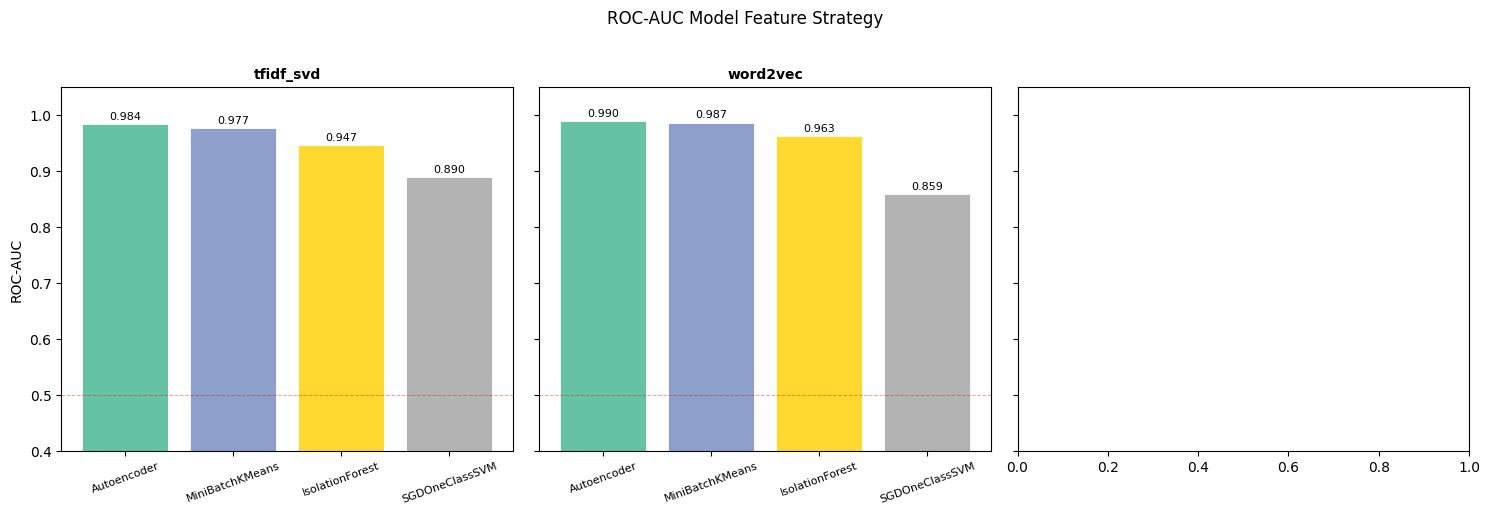

In [10]:
strats      = list(strategies.keys())
models_list = df['model'].unique()
colors      = plt.cm.Set2(np.linspace(0, 1, len(models_list)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, strat in zip(axes, strats):
    sub  = df[df['strategy'] == strat].set_index('model')
    vals = [float(sub.loc[m, 'roc_auc']) if m in sub.index else 0.0 for m in models_list]
    bars = ax.bar(models_list, vals, color=colors, edgecolor='white', linewidth=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(strat, fontsize=10, fontweight='bold')
    ax.set_ylim(0.4, 1.05)
    ax.set_ylabel('ROC-AUC' if ax == axes[0] else '')
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=0.7, alpha=0.4, label='random')

plt.suptitle('ROC-AUC Model Feature Strategy', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'results_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()